In [2]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections


# Other Libraries
from imblearn.datasets import fetch_datasets
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

In [3]:
df_original = pd.read_csv('balanced_data.csv')
df= df_original.copy()

In [4]:
df["Class"]= df["Class"].apply( lambda x: 1 if x==1 else -1)

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,customer_id,phone_number,Class
0,-1.128302,-10.645800,5.918307,-11.671043,8.807369,-7.975501,-3.586806,-13.616797,6.428169,-7.368451,...,-1.667801,0.558419,-0.027898,0.354254,0.273329,-0.152908,-0.353229,42757,+1-773-960-4847,1
1,-1.969039,-1.379848,0.536720,2.647870,1.408111,0.126442,0.986525,0.960251,-0.629717,1.729173,...,0.022138,0.093532,0.011293,-0.503395,-0.438189,-0.346731,-0.178113,1687,+1-683-874-6323,-1
2,-0.473527,-4.198735,0.194121,-3.917586,3.920748,-1.875486,-2.118933,-3.614445,1.687884,-2.189871,...,-0.440387,0.292539,-0.144967,-0.251744,1.249414,-0.131525,0.601913,111691,+1-923-689-4564,1
3,-0.339640,-0.671155,1.183971,0.793623,-0.218410,0.357282,-0.023707,0.363563,0.463983,-0.704518,...,-0.092199,-0.764804,-0.292712,0.185362,-0.028254,0.055953,-0.348032,128361,+1-577-512-7200,-1
4,-1.338649,1.087002,0.065459,0.485043,1.343874,-0.283361,0.002520,-0.076665,0.165384,0.151865,...,-0.048042,0.208209,0.571482,-0.340377,0.028643,0.007649,-0.279025,20747,+1-294-596-8743,-1


In [6]:

# Drop the specified columns
df_new = df.drop(columns=['customer_id', 'phone_number'])

# Show the first 10 rows of the new DataFrame
print(df_new.head(10))

       Time         V1         V2         V3        V4        V5        V6  \
0 -1.128302 -10.645800   5.918307 -11.671043  8.807369 -7.975501 -3.586806   
1 -1.969039  -1.379848   0.536720   2.647870  1.408111  0.126442  0.986525   
2 -0.473527  -4.198735   0.194121  -3.917586  3.920748 -1.875486 -2.118933   
3 -0.339640  -0.671155   1.183971   0.793623 -0.218410  0.357282 -0.023707   
4 -1.338649   1.087002   0.065459   0.485043  1.343874 -0.283361  0.002520   
5 -1.267263   0.333499   1.699873  -2.596561  3.643945 -0.585068 -0.654659   
6 -0.636557   1.080433   0.962831  -0.278065  2.743318  0.412364 -0.320778   
7  0.741600  -0.525485  -0.072842  -1.563655  0.479742 -0.190838  0.598794   
8 -0.560285 -13.192671  12.785971  -9.906650  3.320337 -4.801176  5.760059   
9 -1.902623  -2.303350   1.759247  -0.359745  2.330243 -0.821628 -0.075788   

          V7         V8        V9  ...        V21       V22       V23  \
0 -13.616797   6.428169 -7.368451  ...   2.571970  0.206809 -1.66780

In [7]:
#Check the missing data
missing_data= np.sum( df_new.isnull(), axis=0 )
missing_features=[ feature for feature in missing_data.index if missing_data[feature]>0 ]
missing_features

[]

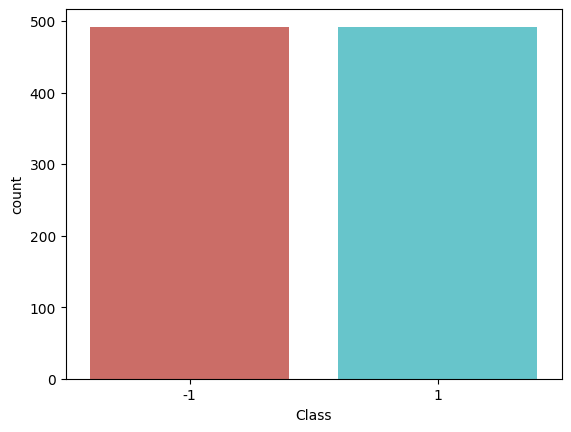

In [8]:
#unitary data analysis
#2.1. Data analysis: unitary data analysis
sns.countplot(x='Class',data=df_new, palette='hls')
plt.show()

In [9]:
num_fraud=np.sum( df_new["Class"]== 1 )
num_non_fraud=np.sum( df_new["Class"]== -1 )
print("fraction of fraud "+ str(num_fraud/ (num_non_fraud+ num_fraud)  ) )

fraction of fraud 0.5


In [10]:
# train test split
X= df_new.loc[:, df_new.columns !='Class'];
y= df_new.loc[:, 'Class'];

X_train, X_tem, y_train, y_tem= train_test_split(X, y, test_size=0.5, random_state=0);
X_val, X_test, y_val, y_test= train_test_split(X_tem, y_tem, test_size=0.6, random_state=0);

In [11]:
len(X_train), len(X_val), len(X_test)

(492, 196, 296)

In [12]:
#Make X_train, y_train balanced

from imblearn.over_sampling import SMOTE

os=SMOTE(random_state=0);
os_X_train, os_y_train= os.fit_resample(X_train, y_train);
os_X_train= pd.DataFrame( data= os_X_train, columns= X_train.columns );
os_y_train= pd.DataFrame( data= os_y_train, columns=['Class'] );


os_X_val, os_y_val= os.fit_resample(X_val, y_val);
os_X_val= pd.DataFrame( data= os_X_val, columns= X_val.columns );
os_y_val= pd.DataFrame( data= os_y_val, columns=['Class'] );

# we can Check the numbers of our data
print("length of oversampled data is ",len(os_X_train))
print("Number of no subscription in oversampled data", sum(os_y_train['Class']==-1) );
print("Number of subscription",sum(os_y_train['Class']==1) );
print("Proportion of no subscription data in oversampled data is ",sum(os_y_train['Class']==-1)/len(os_X_train) )
print("Proportion of subscription data in oversampled data is ",sum(os_y_train['Class']==1)/len(os_X_train) )

print("length of oversampled data is ",len(os_X_val))
print("Number of no subscription in oversampled data", sum(os_y_val['Class']==-1) );
print("Number of subscription",sum(os_y_val['Class']==1) );
print("Proportion of no subscription data in oversampled data is ",sum(os_y_val['Class']==-1)/len(os_X_val) )
print("Proportion of subscription data in oversampled data is ",sum(os_y_val['Class']==1)/len(os_X_val) )

length of oversampled data is  518
Number of no subscription in oversampled data 259
Number of subscription 259
Proportion of no subscription data in oversampled data is  0.5
Proportion of subscription data in oversampled data is  0.5
length of oversampled data is  208
Number of no subscription in oversampled data 104
Number of subscription 104
Proportion of no subscription data in oversampled data is  0.5
Proportion of subscription data in oversampled data is  0.5


In [13]:
#Start to train the model from discovering the best class_weight
#Non-fraud and fraud classes have the same weight in loss function
C=1
clf = LogisticRegression( penalty='l2', tol=0.0001, C=C, fit_intercept=True, solver='liblinear', max_iter=1000)
clf.fit(os_X_train, os_y_train)
y_val_pre= clf.predict(os_X_val)
print( accuracy_score(y_val_pre, os_y_val ) )  

from sklearn.metrics import confusion_matrix
y_val_pred= clf.predict(X_val)
confusion_matrix = confusion_matrix(y_val, y_val_pred)
print(confusion_matrix)

from sklearn.metrics import classification_report
print(classification_report(y_val, y_val_pred))

0.9375
[[87  5]
 [ 8 96]]
              precision    recall  f1-score   support

          -1       0.92      0.95      0.93        92
           1       0.95      0.92      0.94       104

    accuracy                           0.93       196
   macro avg       0.93      0.93      0.93       196
weighted avg       0.93      0.93      0.93       196



In [14]:
#Reduce the weight of fraud class in the loss function to reduce the false positive predictions
#The best class_weight 
C=1
clf = LogisticRegression( penalty='l2', tol=0.0001, C=C, class_weight={-1: 1, 1: 0.01},fit_intercept=True, solver='liblinear', max_iter=1000)
clf.fit(os_X_train, os_y_train)
y_val_pre= clf.predict(os_X_val)
print( accuracy_score(y_val_pre, os_y_val ) ) 

from sklearn.metrics import confusion_matrix
y_val_pred= clf.predict(X_val)
confusion_matrix = confusion_matrix(y_val, y_val_pred)
print(confusion_matrix)

from sklearn.metrics import classification_report
print(classification_report(y_val, y_val_pred))

0.8990384615384616
[[92  0]
 [21 83]]
              precision    recall  f1-score   support

          -1       0.81      1.00      0.90        92
           1       1.00      0.80      0.89       104

    accuracy                           0.89       196
   macro avg       0.91      0.90      0.89       196
weighted avg       0.91      0.89      0.89       196



In [15]:
#Keep reduce the weight of fraud class to 0.001, the number of false negative increases dramatically.
C=1
clf = LogisticRegression( penalty='l2', tol=0.0001, C=C, class_weight={-1: 1, 1: 0.001},fit_intercept=True, solver='liblinear', max_iter=1000)
clf.fit(os_X_train, os_y_train)
y_val_pre= clf.predict(os_X_val)
print( accuracy_score(y_val_pre, os_y_val ) ) 

from sklearn.metrics import confusion_matrix
y_val_pred= clf.predict(X_val)
confusion_matrix = confusion_matrix(y_val, y_val_pred)
print(confusion_matrix)

from sklearn.metrics import classification_report
print(classification_report(y_val, y_val_pred))

0.8701923076923077
[[92  0]
 [27 77]]
              precision    recall  f1-score   support

          -1       0.77      1.00      0.87        92
           1       1.00      0.74      0.85       104

    accuracy                           0.86       196
   macro avg       0.89      0.87      0.86       196
weighted avg       0.89      0.86      0.86       196



In [16]:
#So that class_weight={-1: 1, 1: 0.01} is the best for this dataset. Let's fix the weights and 
#        find the best C: the penaty strength.
Cs=[0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]
accuracies=[]    
for C in Cs:
    clf = LogisticRegression( penalty='l1', tol=0.0001, C=C,class_weight={-1: 1, 1: 0.01}, fit_intercept=True, solver='liblinear', max_iter=1000)
    clf.fit(os_X_train, os_y_train)
    y_val_pre= clf.predict(os_X_val)
    accuracies.append(  accuracy_score(y_val_pre, os_y_val ) )
    
for C in Cs:
    clf = LogisticRegression( penalty='l2', tol=0.0001, C=C, class_weight={-1: 1, 1: 0.01}, fit_intercept=True, solver='liblinear', max_iter=1000)
    clf.fit(os_X_train, os_y_train)
    y_val_pre= clf.predict(os_X_val)
    accuracies.append(  accuracy_score(y_val_pre, os_y_val ) )  

In [17]:
#Get the best C which has the best accuracy in validation dataset.
accuracies.index(max(accuracies) )
Cs[ accuracies.index(max(accuracies) ) -len(Cs) ]

300

In [18]:
#Class_weight and C are decided. Test the model in test dataset.
y_test_pre= clf.predict(X_test)
print( accuracy_score(y_test_pre, y_test ) ) 

from sklearn.metrics import confusion_matrix
y_test_pred= clf.predict(X_test)
my_confusion_matrix = confusion_matrix(y_test, y_test_pred)
print(my_confusion_matrix)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

0.9290540540540541
[[138   3]
 [ 18 137]]
              precision    recall  f1-score   support

          -1       0.88      0.98      0.93       141
           1       0.98      0.88      0.93       155

    accuracy                           0.93       296
   macro avg       0.93      0.93      0.93       296
weighted avg       0.93      0.93      0.93       296



In [23]:
# #extract the coefficients, use them to build our own logistic classifier in Flink 
# w= clf.coef_.reshape( (30, 1) )
# b= clf.intercept_
# print("Model Coefficients:")
# print(w)

# print("Model Intercept:")
# print(b)


# Extract the coefficients and build the logistic classifier
w = clf.coef_.reshape((30, 1))
b = clf.intercept_

print("Model Coefficients:")
for i, coeff in enumerate(w):
    print(f"Weight {i+1}: {coeff[0]}")

print("Model Intercept:")
print(b)

Model Coefficients:
Weight 1: -1.1289703378295965
Weight 2: 1.721698472278388
Weight 3: -0.24255950063396547
Weight 4: 0.24892234577791233
Weight 5: 1.9141632896069147
Weight 6: 1.6672821738741157
Weight 7: -0.6738153672233783
Weight 8: -2.0272543599508
Weight 9: -2.257822378857633
Weight 10: -1.400879228345609
Weight 11: -2.759592866465892
Weight 12: 2.495743641290426
Weight 13: -2.164850087938599
Weight 14: -0.4068735755971469
Weight 15: -4.28959155425175
Weight 16: 0.9730412736842141
Weight 17: -1.4524196767355433
Weight 18: -2.6469344450945895
Weight 19: -1.1325173729393654
Weight 20: 2.021227229253037
Weight 21: -2.092856154918522
Weight 22: 0.38622384737940774
Weight 23: 1.3171863423202503
Weight 24: -1.2101073166098935
Weight 25: 0.7334094830753759
Weight 26: -0.45936346537755374
Weight 27: 1.300548268038039
Weight 28: -0.9858705269679775
Weight 29: 0.8449109972953374
Weight 30: 2.983890059595085
Model Intercept:
[-11.04842724]


In [20]:
import joblib

# Step 18: Save the trained model
joblib.dump(clf, 'rtfs_model.pkl')
print("Trained model saved to 'rtfs_model.pkl'")

Trained model saved to 'rtfs_model.pkl'
